# Baseline Modelling

Tujuan: Notebook ini bertujuan membangun **baseline classification model** untuk memprediksi hasil pertandingan sepak bola internasional menggunakan fitur-fitur dasar yang telah dihasilkan pada tahap *Feature Engineering*. Model baseline ini akan menjadi acuan utama sebelum dilakukan pengembangan fitur historis seperti performa lima pertandingan terakhir, rata-rata gol, hingga Elo Rating pada fase berikutnya.

## 1. Loading

Memuat dataset `baseline_features` yang telah disimpan pada tahap sebelumnya. 

In [41]:
import pandas as pd

In [42]:
df = pd.read_csv('../data/processed/baseline_features.csv')

In [43]:
df.head()

,date,home_team,away_team,tournament,neutral,match_result
0,1872-11-30,Scotland,England,Friendly,False,D
1,1873-03-08,England,Scotland,Friendly,False,H
2,1874-03-07,Scotland,England,Friendly,False,H
3,1875-03-06,England,Scotland,Friendly,False,D
4,1876-03-04,Scotland,England,Friendly,False,H


In [44]:
df.shape

(49433, 6)

Data sudah berhasil di load kembali dan siap digunakan.

## 2. Feature & Target Separation

Dataset yang telah dipersiapkan pada tahap sebelumnya
berisi fitur-fitur yang tersedia sebelum pertandingan dimulai
serta satu variabel target (`match_result`).

Pada tahap ini dataset dipisahkan menjadi:

- Feature (`X`)
- Target (`y`)

In [45]:
X = df.drop(columns=["match_result"])

y = df["match_result"]

## 3. Time-based Train-Test Split

 Sebelum membangun model, dataset perlu dibagi menjadi data latih (*training set*) dan data uji (*testing set*). Berbeda dengan sebagian besar dataset tabular yang menggunakan pembagian secara acak (*random split*), penelitian ini menggunakan *time-based split*. Pendekatan ini dipilih agar model hanya mempelajari pertandingan yang terjadi di masa lalu dan dievaluasi menggunakan pertandingan yang terjadi setelahnya. Dengan demikian, proses evaluasi lebih merepresentasikan kondisi nyata serta membantu mengurangi risiko *data leakage* akibat penggunaan informasi dari masa depan.

### 3.1 Menentukan Urutan

Kita harus memastikan dataset sudah urut berdasarkan tanggal.

In [46]:
df["date"].is_monotonic_increasing

False

Ternyata dataset belum urut. Kita akan urutkan terlebih dahulu berdasarkan tanggal.

In [47]:
df = df.sort_values("date").reset_index(drop=True)

In [48]:
df["date"].is_monotonic_increasing

True

Dataset berhasil di urutkan.

### 3.2 Split Dataset

Keputusannya, data akan di split 80:20 berdasarkan urutan tanggal.

In [49]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

### 3.3 Pisahkan Feature dan Target

Kita pisahkan fitur dan target untuk data train dan test.

In [50]:
# TRAIN
X_train = train_df.drop(columns=["match_result"])
y_train = train_df["match_result"]

# TEST
X_test = test_df.drop(columns=["match_result"])
y_test = test_df["match_result"]

### 3.4 Verifikasi
Memastikan proses berjalan lancar.

In [51]:
print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")

Train : (39546, 6)
Test  : (9887, 6)


In [52]:
print(train_df["date"].min(), "-", train_df["date"].max())
print(test_df["date"].min(), "-", test_df["date"].max())

1872-11-30 - 2016-03-25
2016-03-25 - 2026-06-18



### 3.5 Insight

Dataset berhasil dibagi menggunakan pendekatan *time-based split* dengan proporsi
80% data latih dan 20% data uji berdasarkan urutan kronologis pertandingan.
Pendekatan ini memastikan model hanya mempelajari informasi dari masa lalu dan
dievaluasi menggunakan pertandingan yang terjadi setelahnya, sehingga proses
evaluasi menjadi lebih realistis serta membantu meminimalkan risiko *data leakage*.

## 4. Modeling Pipeline
Kita akan mulai membangun model.

### 4.1 Feature Types
Sebelum membangun model, fitur-fitur perlu dikelompokkan berdasarkan tipe datanya. Pada dataset baseline ini, seluruh fitur yang digunakan masih berupa data kategorikal (`home_team`, `away_team`, `tournament`, dan `neutral`). Oleh karena itu, fitur-fitur tersebut akan diubah menjadi representasi numerik menggunakan **One-Hot Encoding** melalui *Pipeline* sehingga proses transformasi hanya dipelajari dari data latih dan diterapkan secara konsisten pada data uji.

In [53]:
X_train.dtypes

date           str
home_team      str
away_team      str
tournament     str
neutral       bool
dtype: object

### 4.2 Preprocessing Pipeline

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [55]:
categorical_features = [
    "home_team",
    "away_team",
    "tournament",
    "neutral"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="drop",
)

#### Mengapa menggunakan Pipeline?

Pipeline membantu menggabungkan proses transformasi fitur dan pelatihan model ke dalam satu alur kerja. Pendekatan ini membuat proses lebih konsisten, mengurangi risiko *data leakage*, serta memudahkan pengujian berbagai algoritma tanpa perlu mengulangi proses *preprocessing*.

### 4.3 Logistic Regression


Pertama, menggunakan Logistic Regression.

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

Kita menggunakan max_iter=1000 karena One-Hot Encoding sering menghasilkan banyak fitur, dan dilakukan agar tidak mudah muncul warning convergence.

In [58]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [59]:
lr_pred = lr_pipeline.predict(X_test)

### 4.4 Random Forest

Kedua, dengan Random Forest.

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            ),
        ),
    ]
)

In [62]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [63]:
rf_pred = rf_pipeline.predict(X_test)

### 4.5 Save Model
Simpan model.

In [73]:
import joblib

joblib.dump(
    lr_pipeline,
    "../models/logistic_regression_baseline.pkl"
)

joblib.dump(
    rf_pipeline,
    "../models/random_forest_baseline.pkl"
)

['../models/random_forest_baseline.pkl']

## 5. Model Evaluation
Setelah beberapa pipeline model tadi, kita akan memulai evaluasi.

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

### 5.1 Logistic Rergression
Evaluasi Logistic Regression.

In [65]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted",
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted",
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted",
)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Accuracy : 0.5730
Precision: 0.5214
Recall   : 0.5730
F1 Score : 0.5096


In [66]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           A       0.55      0.53      0.54      2868
           D       0.34      0.05      0.08      2305
           H       0.59      0.86      0.70      4714

    accuracy                           0.57      9887
   macro avg       0.49      0.48      0.44      9887
weighted avg       0.52      0.57      0.51      9887



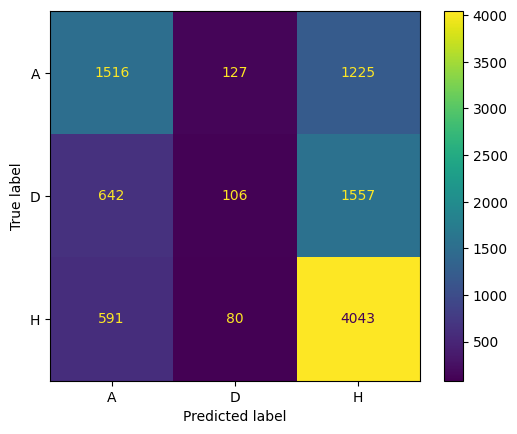

In [67]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

### 5.2 Random Forest
Evaluasi Random Forest.

In [68]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted",
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted",
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted",
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.5084
Precision: 0.4709
Recall   : 0.5084
F1 Score : 0.4784


In [71]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           A       0.46      0.42      0.44      2868
           D       0.28      0.14      0.18      2305
           H       0.57      0.75      0.65      4714

    accuracy                           0.51      9887
   macro avg       0.44      0.43      0.42      9887
weighted avg       0.47      0.51      0.48      9887



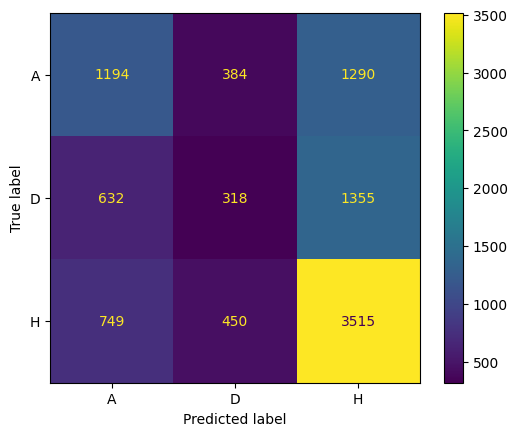

In [72]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

### 5.3 Comparison
Bandingkan dan evaluasi kedua model.

#### Perbandingan Kedua Model

| Model               |   Accuracy |  Precision |     Recall |   F1 Score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression | **0.5730** | **0.5214** | **0.5730** | **0.5096** |
| Random Forest       |     0.5084 |     0.4709 |     0.5084 |     0.4784 |


#### Insight Comparison

Berdasarkan hasil evaluasi, **Logistic Regression** memberikan performa yang lebih baik dibandingkan **Random Forest** pada seluruh metrik evaluasi, termasuk accuracy, precision, recall, dan F1-score.

Hasil ini menunjukkan bahwa hubungan antara fitur-fitur dasar yang digunakan pada model baseline masih dapat dipelajari dengan baik oleh model linear. Dengan kata lain, informasi yang berasal dari identitas tim, jenis turnamen, dan status kandang/tandang telah memberikan sinyal prediktif yang cukup kuat tanpa memerlukan model yang lebih kompleks.

Meskipun demikian, performa kedua model masih tergolong moderat. Hal ini mengindikasikan bahwa fitur-fitur dasar saja belum cukup untuk menjelaskan seluruh variasi hasil pertandingan sepak bola internasional. Oleh karena itu, penambahan fitur historis seperti performa beberapa pertandingan terakhir, rata-rata gol, serta Elo Rating pada tahap berikutnya diharapkan mampu meningkatkan kemampuan prediksi model secara signifikan.

### 5.4 Save Reports
Simpan hasil laporan evaluasi.

In [74]:
import pandas as pd

baseline_metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1]
})

baseline_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.572975,0.521363,0.572975,0.509571
1,Random Forest,0.508445,0.470924,0.508445,0.478398


In [75]:
baseline_metrics.to_csv(
    "../reports/baseline_metrics.csv",
    index=False
)

## 6. Baseline Modeling Summary

Pada tahap ini berhasil dibangun dua model baseline, yaitu **Logistic Regression** dan **Random Forest**, menggunakan fitur-fitur dasar hasil *Feature Engineering*. Seluruh proses pelatihan dilakukan melalui *Pipeline* yang menggabungkan *One-Hot Encoding* dan algoritma klasifikasi sehingga proses transformasi fitur berlangsung secara konsisten tanpa menimbulkan *data leakage*.

Berdasarkan hasil evaluasi, **Logistic Regression** memberikan performa terbaik dengan nilai accuracy sebesar **57,30%**, mengungguli Random Forest pada seluruh metrik evaluasi. Meskipun demikian, kedua model masih mengalami kesulitan dalam mengenali pertandingan yang berakhir imbang (*Draw*), yang terlihat dari rendahnya nilai *recall* pada kelas tersebut. Temuan ini menunjukkan bahwa fitur-fitur dasar seperti identitas tim, jenis turnamen, dan status kandang belum sepenuhnya mampu merepresentasikan kekuatan relatif kedua tim. Oleh karena itu, tahap berikutnya akan berfokus pada pembangunan fitur historis seperti performa beberapa pertandingan terakhir, rata-rata gol, serta Elo Rating untuk meningkatkan kemampuan prediksi model.